In [1]:
import pandas as pd

df = pd.read_csv('mexico_covid19.csv')
print(df["RESULTADO"].unique())
translation_dict = {
    "FECHA_ARCHIVO": "report_date",
    "ID_REGISTRO": "registry_id",
    "ENTIDAD_UM": "medical_unit_state",
    "ENTIDAD_RES": "residence_state",
    "RESULTADO": "result", #RT-PCR test result
    "DELAY": "days_to_confirmation",
    "ENTIDAD_REGISTRO": "registration_state",
    "ENTIDAD": "state_name",
    "ABR_ENT": "state_abbreviation",
    "FECHA_ACTUALIZACION": "update_date",
    "ORIGEN": "origin",
    "SECTOR": "sector",
    "SEXO": "sex",
    "ENTIDAD_NAC": "birth_state",
    "MUNICIPIO_RES": "residence_municipality",
    "TIPO_PACIENTE": "patient_type",
    "FECHA_INGRESO": "admission_date",
    "FECHA_SINTOMAS": "symptoms_onset_date",
    "FECHA_DEF": "death_date",
    "INTUBADO": "intubated",
    "NEUMONIA": "pneumonia",
    "EDAD": "age",
    "NACIONALIDAD": "nationality",
    "EMBARAZO": "pregnant",
    "HABLA_LENGUA_INDIG": "speaks_indigenous_language",
    "DIABETES": "diabetes",
    "EPOC": "COPD",
    "ASMA": "asthma",
    "INMUSUPR": "immunosuppressed",
    "HIPERTENSION": "hypertension",
    "OTRA_COM": "other_comorbidity",
    "CARDIOVASCULAR": "cardiovascular",
    "OBESIDAD": "obesity",
    "RENAL_CRONICA": "chronic_renal_failure",
    "TABAQUISMO": "tobacco_use",
    "OTRO_CASO": "contact_with_other_case",
    "MIGRANTE": "migrant",
    "PAIS_NACIONALIDAD": "nationality_country",
    "PAIS_ORIGEN": "origin_country",
    "UCI": "ICU",
}

df = df.rename(columns=translation_dict)

print(df["registration_state"].unique()) #registrato belongs to catalogo de entidades
print(df["residence_state"].unique())  
print(df["residence_municipality"].unique()) #cant be bothered
df["sector"].unique()
print(df["registry_id"].nunique())
print(len(df))

[2 1]
[25 14  8  9 19 17 27 15  5 28 11 24 31  2 21 32 13  3 26 16 30  1 10 12
 20 29 18  7 22 23  6  4]
[25 14  8 15  9 19 17 27  5 28 11 24 31  2 21 32 13  3 26 16 30  1 10 12
 20 29 18  7 22 23  6  4]
[ 13.  98.  19.  33.  15.  39.  12.   4.  20.   3.  18.  26.   5.  38.
  17.  28.   2.  11.  67.  50.  97.  90. 114.  51. 106.   1.   8.  30.
  69.  16. 124.  37.   7.  10.  35. 193. 120.  14.   6.  46.  66.  23.
  48. 109.  25.  83. 178.  77.  72.  31. 156. 105. 101.  59.  27.  57.
  53.  93.  24.  99.  44.  41.  70.  81. 104.  22.  56.  54.   9. 121.
  21. 413. 118.  61. 102. 350.  32.  43. 169. 206.  76. 399. 119.  71.
 140. 173.  58.  29. 157. 185. 324. 122. 108. 107.  73. 117.  40. 184.
  47.  60.  87.  63.  42.  68.  36. 112.  96.  65. 254. 138.  nan 136.
  55.  85. 131.  88. 483.  74. 141. 549.  34.  45. 191.  52. 385. 334.
 409.  49.  64. 474.  75. 196.  80. 100. 133.  89. 181. 553. 125. 142.
 126.  78.  86. 129. 390.  84.  94. 214. 174. 110. 318.  82. 111. 154.
  62. 227. 113.

In [2]:
# we dont translate municipios we dont think there is anything usefull there

# YES/NO catalog: 1=Yes, 2=No, 97=N/A, 98=Ignored, 99=Not specified this is from the catalogo si_no
yes_no_map = {1: 'Yes', 2: 'No', 97: 'N/A', 98: 'Ignored', 99: 'Not specified'}
yes_no_cols = [
    'intubated', 'pneumonia', 'pregnant', 'speaks_indigenous_language',
    'diabetes', 'COPD', 'asthma', 'immunosuppressed', 'hypertension',
    'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_renal_failure',
    'tobacco_use', 'contact_with_other_case', 'migrant', 'ICU',
]
for col in yes_no_cols:
    df[col] = df[col].map(yes_no_map)

# ORIGEN catalogo origin
df['origin'] = df['origin'].map({1: 'USMER', 2: 'Outside USMER', 99: 'Not specified'})

# SECTOR catalogo sector
df['sector'] = df['sector'].map({
    1: 'Red Cross', 2: 'DIF', 3: 'State', 4: 'IMSS', 5: 'IMSS-Bienestar',
    6: 'ISSSTE', 7: 'Municipal', 8: 'PEMEX', 9: 'Private',
    10: 'SEDENA (Army)', 11: 'SEMAR (Navy)', 12: 'SSA (Ministry of Health)',
    13: 'University', 99: 'Not specified',
})

# SEXO catalogo sexo
df['sex'] = df['sex'].map({1: 'Female', 2: 'Male', 99: 'Not specified'})

# TIPO_PACIENTE catalogo tipo_paciente
df['patient_type'] = df['patient_type'].map({1: 'Outpatient', 2: 'Hospitalized', 99: 'Not specified'})

# NACIONALIDAD catalogo naciionalidad
df['nationality'] = df['nationality'].map({1: 'Mexican', 2: 'Foreign', 99: 'Not specified'})

# RESULTADO
df['result'] = df['result'].map({
    1: 'Positive', 2: 'Negative'
})

# Mexican state codes (ENTIDAD_UM, ENTIDAD_RES, ENTIDAD_NAC, ENTIDAD_REGISTRO) catalogo de entidades
state_map = {
    1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur',
    4: 'Campeche', 5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua',
    9: 'Ciudad de México', 10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero',
    13: 'Hidalgo', 14: 'Jalisco', 15: 'Estado de México', 16: 'Michoacán',
    17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León', 20: 'Oaxaca',
    21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
    25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas',
    29: 'Tlaxcala', 30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas', 36:'Mexico',
    97: 'N/A', 98: 'Ignored', 99: 'Not specified',
}
for col in ['medical_unit_state', 'residence_state', 'birth_state', 'registration_state']:
    df[col] = df[col].map(state_map)

# Date columns — replace death_date sentinel then convert all to datetime
df['death_date'] = df['death_date'].replace('9999-99-99', None)

date_cols = ['report_date', 'update_date', 'admission_date', 'symptoms_onset_date', 'death_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

df

,id,report_date,registry_id,medical_unit_state,residence_state,result,days_to_confirmation,registration_state,state_name,state_abbreviation,...,other_comorbidity,cardiovascular,obesity,chronic_renal_failure,tobacco_use,contact_with_other_case,migrant,nationality_country,origin_country,ICU
0,9269,2020-04-12,00011f,Sinaloa,Sinaloa,Negative,0,Sinaloa,Sinaloa,SL,...,No,No,Yes,No,No,No,Not specified,MÃ©xico,97,N/A
1,33333,2020-04-12,00014e,Jalisco,Jalisco,Negative,0,Jalisco,Jalisco,JC,...,No,No,Yes,No,Yes,Not specified,Not specified,MÃ©xico,97,No
2,35483,2020-04-12,000153,Chihuahua,Chihuahua,Positive,0,Chihuahua,Chihuahua,CH,...,No,No,No,No,No,Not specified,Not specified,MÃ©xico,97,No
3,7062,2020-04-12,0001b6,Ciudad de México,Estado de México,Positive,0,Ciudad de México,Ciudad de Mexico,DF,...,No,No,Yes,No,No,Not specified,Not specified,MÃ©xico,97,N/A
4,23745,2020-04-12,0001c1,Ciudad de México,Ciudad de México,Negative,0,Ciudad de México,Ciudad de Mexico,DF,...,No,No,No,No,No,Not specified,Not specified,MÃ©xico,97,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263002,7094887,2020-06-03,1e019c,Zacatecas,Zacatecas,Positive,0,Zacatecas,Zacatecas,ZS,...,No,No,No,No,No,Yes,Not specified,MÃ©xico,99,N/A
263003,7053721,2020-06-03,1e2b05,Guerrero,Guerrero,Positive,0,Guerrero,Guerrero,GR,...,No,No,Yes,No,No,Not specified,Not specified,MÃ©xico,99,No
263004,7055429,2020-06-03,1e473f,Oaxaca,Oaxaca,Positive,0,Oaxaca,Oaxaca,OC,...,No,No,No,Yes,No,Not specified,Not specified,MÃ©xico,99,No
263005,7043768,2020-06-03,1e6da1,Hidalgo,Hidalgo,Positive,0,Hidalgo,Hidalgo,HG,...,No,No,No,No,No,No,Not specified,MÃ©xico,99,No


# Section A — Problem Formulation & Dataset Analysis

**Prediction task.** Binary **classification**: using only information available at a patient's *initial presentation* to a sentinel unit, predict whether that patient will be **hospitalized** (`patient_type` = Hospitalized) rather than treated as an outpatient. We restrict to **RT-PCR-positive** patients, so the task reads: *among lab-confirmed COVID-19 patients presenting at a sentinel unit, who gets admitted?*

- **Target:** `patient_type == 'Hospitalized'` (1) vs `Outpatient` (0).
- **Prediction population:** symptomatic, lab-confirmed COVID-19 patients evaluated at the 475 SISVER sentinel units (data spans Apr–Jun 2020).
- **Prediction moment:** first clinical contact / registration.
- **Prediction horizon:** the admission decision for the current episode.
- **Information at prediction time:** demographics, registration metadata, and pre-existing comorbidities. Variables recorded at or after admission/discharge (intubation, ICU, in-hospital pneumonia, death) are treated as leakage — see the leakage audit below.

**Population interpretation & collection bias.** SISVER rationed testing by severity: 100% of severe/SARI patients but only ~10% of mild symptomatic patients were tested, and asymptomatic people essentially never. Confirmed positives are therefore **over-weighted toward severe presentations**, so the hospitalization rate we model is *not* a population-level admission probability for everyone infected — it is the admission rate *within this severity-skewed, testing-selected sample*. The **dataset population** (tested, mostly severe presentations at sentinel units) is narrower than the **target population** we would like to generalize to (all symptomatic COVID-19 patients), and this selection bias limits generalization. We do not attempt to correct it; instead we interpret results conditional on this sampling.

> **[V2 CHANGE]** In this version the cohort is **not** restricted to positive tests by default — all presenting patients are included (see the `INCLUDE_ONLY_POSITIVE` flag in the cohort cell). Set that flag to `True` to restore the original positives-only cohort described above.

In [3]:
# --- Reproducibility ---
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ===== [V2 CHANGED] Cohort is no longer restricted to positive tests by default. =====
# v1 kept ONLY positive RT-PCR patients:
#     cohort = df[df['result'] == 'Positive'].copy()
# v2 includes ALL presenting patients by default. To revert to the original
# positives-only cohort, set the flag below to True (or delete this block and
# restore the single commented line above).
INCLUDE_ONLY_POSITIVE = False
if INCLUDE_ONLY_POSITIVE:
    cohort = df[df['result'] == 'Positive'].copy()
    print(f"[cohort] positives only: {len(cohort):,} records")
else:
    cohort = df.copy()
    print(f"[cohort] all patients (positivity filter OFF): {len(cohort):,} records")
# ===== end [V2 CHANGED] =====

# --- De-duplicate repeated patient records ---
# The source is a stack of daily archive snapshots (report_date); the same
# registry_id can appear on several days. Keep the latest snapshot per patient.


# --- Target: hospitalized (1) vs outpatient (0) ---
cohort = cohort[cohort['patient_type'].isin(['Outpatient', 'Hospitalized'])].copy()
cohort['target'] = (cohort['patient_type'] == 'Hospitalized').astype(int)

print("\nClass distribution (0 = Outpatient, 1 = Hospitalized):")
print(cohort['target'].value_counts().sort_index())
print(f"Hospitalization prevalence: {cohort['target'].mean():.3f}")


[cohort] all patients (positivity filter OFF): 263,007 records

Class distribution (0 = Outpatient, 1 = Hospitalized):
target
0    200838
1     62169
Name: count, dtype: int64
Hospitalization prevalence: 0.236


### Feature selection (leakage-aware)

We keep only variables plausibly known at first contact: **age**, **sex**, registration metadata (`sector`, `origin`/USMER, `residence_state`, `nationality`, `contact_with_other_case`), and **pre-existing conditions**. Rather than statistically imputing missing values, we handle each case explicitly:

- **`migrant`** — dropped entirely (99.7% *Not specified*, no signal).
- **`pregnant`** and **`speaks_indigenous_language`** — *not specified* is set to **No (0)** (a fixed domain rule, not learned from data).
- **`contact_with_other_case`** — *not specified* is kept as an explicit third category (`Unknown`).
- **the comorbidity flags (and `age`)** — records that are not filled in are **dropped** (only a small fraction; see the drop report below).

Binary Yes/No fields are encoded `Yes→1`, `No→0`, and categoricals are one-hot encoded. Because every remaining missing value is resolved here, the model pipeline needs **no imputation step**. Variables recorded downstream of the admission decision — `intubated`, `ICU`, `pneumonia`, `death_date`, `days_to_confirmation`, and the various dates — are excluded, because they are not known at the time the admission decision is made.

> **[V2 CHANGES]** `speaks_indigenous_language` is dropped from the feature set, and an engineered feature **`N_COMORBIDITIES`** (count of chronic conditions) is added to the numeric block.

In [4]:
numeric_features = ['age']
comorbidity_cols = [
    'diabetes', 'COPD', 'asthma', 'immunosuppressed', 'hypertension',
    'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_renal_failure',
    'tobacco_use',
]
# ===== [V2 CHANGED] 'speaks_indigenous_language' dropped from the feature set. =====
# v1 was: binary_features = comorbidity_cols + ['pregnant', 'speaks_indigenous_language']
binary_features = comorbidity_cols + ['pregnant']
# ===== end [V2 CHANGED] =====

# Categorical (one-hot). `contact_with_other_case` keeps 'not specified' as a third category;
# `migrant` is dropped entirely (99.7% 'Not specified', no signal).
categorical_features = ['sex', 'sector', 'origin', 'residence_state', 'nationality',
                        'contact_with_other_case']

# Base columns pulled from the cohort (engineered N_COMORBIDITIES is added after cleaning).
base_cols = numeric_features + binary_features + categorical_features

# Modelling frame: leakage-safe features + target.
# Also carry a descriptive-only 'died' flag (from death_date). It is NOT added to
# feature_cols, so it never enters the design matrix X (that would be leakage).
data = cohort[base_cols + ['target']].copy()
data['died'] = cohort['death_date'].notna().astype(int)
data = data.reset_index(drop=True)

# Encode binary Yes/No -> 1/0
binary_map = {'Yes': 1, 'No': 0}
for col in binary_features:
    data[col] = data[col].map(binary_map)

# `pregnant`: not-specified -> No (0). A fixed domain rule, not learned from data.
# ===== [V2 CHANGED] 'speaks_indigenous_language' removed from this fill loop (feature dropped). =====
for col in ['pregnant']:
    data[col] = data[col].fillna(0)
# ===== end [V2 CHANGED] =====

# `contact_with_other_case`: keep 'not specified' as an explicit third category ('Unknown').
data['contact_with_other_case'] = data['contact_with_other_case'].where(
    data['contact_with_other_case'].isin(['Yes', 'No']), 'Unknown')

# The remaining features (comorbidities + age): no imputation — drop rows not filled in.
drop_subset = comorbidity_cols + numeric_features
rows_before = len(data)
missing_per_col = data[drop_subset].isna().sum()
data = data.dropna(subset=drop_subset).reset_index(drop=True)
rows_after = len(data)

# ===== [V2 ADDED] Engineered feature: N_COMORBIDITIES (count of chronic conditions). =====
# Comorbidity flags are clean 0/1 here (rows with any missing flag were dropped above),
# so the row-wise sum is well defined. Added to the NUMERIC block so it is scaled with age.
data['N_COMORBIDITIES'] = data[comorbidity_cols].sum(axis=1).astype(int)
numeric_features = numeric_features + ['N_COMORBIDITIES']
# ===== end [V2 ADDED] =====

# Final feature list (now includes the engineered feature, excludes speaks_indigenous_language)
feature_cols = numeric_features + binary_features + categorical_features

X = data[feature_cols]
y = data['target']

print(f"Design matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Numeric: {numeric_features} | Binary: {len(binary_features)} | Categorical: {categorical_features}")
print(f"Remaining missing values in X: {int(X.isna().sum().sum())}")


Design matrix: 260,933 rows x 19 features
Numeric: ['age', 'N_COMORBIDITIES'] | Binary: 11 | Categorical: ['sex', 'sector', 'origin', 'residence_state', 'nationality', 'contact_with_other_case']
Remaining missing values in X: 0


In [5]:
# How much data did the "drop rows with unfilled comorbidities" rule remove?
dropped = rows_before - rows_after
print("=== Rows dropped for unfilled comorbidity / age values ===")
print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Dropped     : {dropped:,}  ({100 * dropped / rows_before:.2f}%)")

print("\n'Not specified' (missing) count per dropped-on column, before dropping:")
print(missing_per_col[missing_per_col > 0].sort_values(ascending=False))

print(f"\nHospitalization prevalence — before: {cohort['target'].mean():.3f} | "
      f"after: {y.mean():.3f}   (a small change means the drop did not skew the target)")

=== Rows dropped for unfilled comorbidity / age values ===
Rows before : 263,007
Rows after  : 260,933
Dropped     : 2,074  (0.79%)

'Not specified' (missing) count per dropped-on column, before dropping:
other_comorbidity        1344
immunosuppressed         1038
diabetes                 1011
tobacco_use               982
obesity                   962
cardiovascular            961
hypertension              938
chronic_renal_failure     937
COPD                      931
asthma                    923
dtype: int64

Hospitalization prevalence — before: 0.236 | after: 0.234   (a small change means the drop did not skew the target)


### Leakage audit

Prediction moment = initial presentation, so anything recorded at/after admission or discharge is excluded from `X`.

| Variable | Available at prediction time? | Included? | Reason |
|---|---|---|---|
| age, sex | Yes | Yes | Baseline demographics |
| comorbidities (diabetes, COPD, asthma, immunosuppressed, hypertension, cardiovascular, obesity, chronic renal failure, tobacco use, other), pregnant | Yes | Yes | Pre-existing, known at presentation |
| sector, origin (USMER), residence_state, nationality, speaks_indigenous_language, contact_with_other_case | Yes | Yes | Recorded at registration |
| migrant | Yes, but 99.7% `Not specified` | No | Dropped for lack of signal (a data-quality choice, not leakage) |
| **pneumonia** | No — recorded as an in-hospital diagnosis | No | Not known at the time of the admission decision |
| **intubated, ICU** | No | No | Occur only after admission |
| death_date | No | No | Final outcome |
| days_to_confirmation (DELAY) | No | No | Post-presentation lab timing |
| admission_date, report_date, update_date | No | No | Post-presentation / archival |
| result | Defines cohort | No (as feature) | Used only to select positive patients |
| **patient_type** | — | **TARGET** | Hospitalized = 1, Outpatient = 0 |

> **[V2]** `speaks_indigenous_language` removed from features; `N_COMORBIDITIES` (engineered count, known at presentation) added; cohort positivity filter now optional (`INCLUDE_ONLY_POSITIVE`).

### Exploratory analysis (full cohort)

These plots are **descriptive** and use the full cleaned cohort to characterise the data. They inform understanding only — all model fitting, selection, and metrics still respect the train/test split defined above, so no test information leaks into modelling decisions. The plots target: (1) the dominant predictor, age; (2) comorbidity burden and sex; (3) class balance; (4) a dataset-level time series of daily positive cases vs. hospital admissions; and (5) a KMeans clustering of patients on age, sex, and comorbidity count (the outcome is **not** a clustering input), shown as two side-by-side interactive 3D scatters (opened in the browser) — the left coloured by cluster, the right coloured by hospitalization outcome — plus per-cluster profiles.

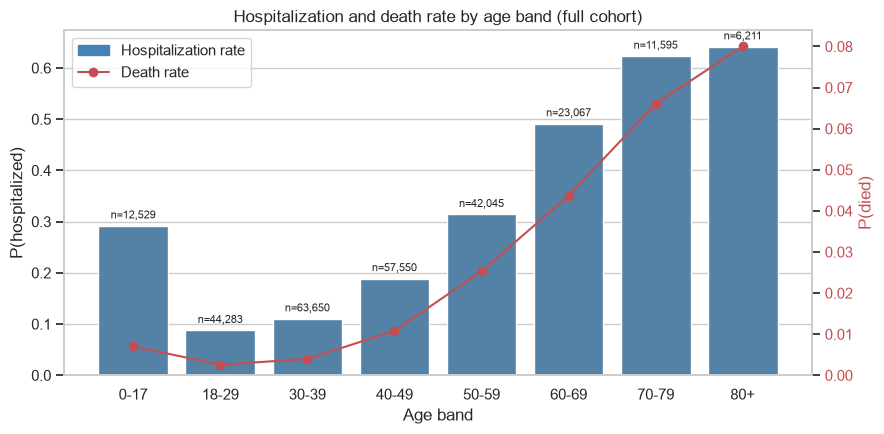

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid')

# EDA plot 1: hospitalization AND death rate by age band (full cohort)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 120]
age_labels = ['0-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
tmp = data.assign(age_band=pd.cut(data['age'], bins=age_bins,
                                  labels=age_labels, right=False))
by_age = tmp.groupby('age_band', observed=True).agg(
    hosp=('target', 'mean'), death=('died', 'mean'), size=('target', 'size'))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=by_age.index, y=by_age['hosp'], color='steelblue', ax=ax)
ax.set_title('Hospitalization and death rate by age band (full cohort)')
ax.set_xlabel('Age band'); ax.set_ylabel('P(hospitalized)')
for i, (m, n) in enumerate(zip(by_age['hosp'], by_age['size'])):
    ax.text(i, m + 0.01, f'n={n:,}', ha='center', va='bottom', fontsize=8)

# Death rate overlaid on a secondary axis (much smaller scale than hospitalization).
ax2 = ax.twinx()
ax2.plot(range(len(by_age)), by_age['death'], 'o-', color='#C44E52')
ax2.set_ylabel('P(died)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(bottom=0); ax2.grid(False)

ax.legend(handles=[Patch(color='steelblue', label='Hospitalization rate'),
                   Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
          loc='upper left')
plt.tight_layout(); plt.show()

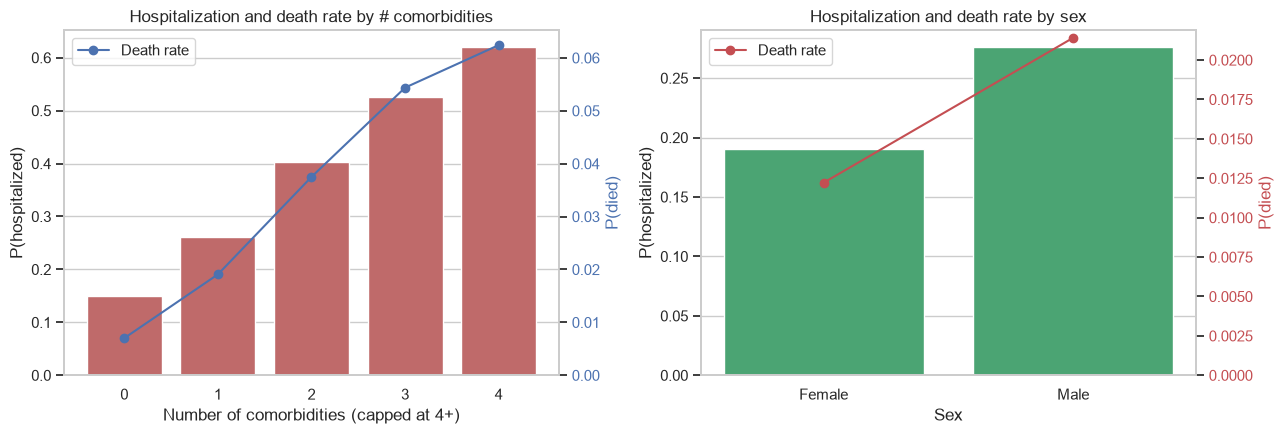

In [7]:
# EDA plot 2: hospitalization AND death rate by comorbidity burden and by sex (full cohort)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: by number of comorbidities ---
n_comorb = data[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4)
comorb_df = pd.DataFrame({'n_comorb': n_comorb.astype(int),
                          'target': data['target'], 'died': data['died']})
by_comorb = comorb_df.groupby('n_comorb').agg(hosp=('target', 'mean'), death=('died', 'mean'))
sns.barplot(x=by_comorb.index, y=by_comorb['hosp'], color='indianred', ax=axes[0])
axes[0].set_title('Hospitalization and death rate by # comorbidities')
axes[0].set_xlabel('Number of comorbidities (capped at 4+)')
axes[0].set_ylabel('P(hospitalized)')
ax0b = axes[0].twinx()
ax0b.plot(range(len(by_comorb)), by_comorb['death'], 'o-', color='#4C72B0')
ax0b.set_ylabel('P(died)', color='#4C72B0')
ax0b.tick_params(axis='y', labelcolor='#4C72B0')
ax0b.set_ylim(bottom=0); ax0b.grid(False)
axes[0].legend(handles=[Line2D([0], [0], color='#4C72B0', marker='o', label='Death rate')],
               loc='upper left')

# --- Right: by sex ---
by_sex = data.groupby('sex').agg(hosp=('target', 'mean'),
                                 death=('died', 'mean')).sort_values('hosp')
sns.barplot(x=by_sex.index, y=by_sex['hosp'], color='mediumseagreen', ax=axes[1])
axes[1].set_title('Hospitalization and death rate by sex')
axes[1].set_xlabel('Sex'); axes[1].set_ylabel('P(hospitalized)')
ax1b = axes[1].twinx()
ax1b.plot(range(len(by_sex)), by_sex['death'], 'o-', color='#C44E52')
ax1b.set_ylabel('P(died)', color='#C44E52')
ax1b.tick_params(axis='y', labelcolor='#C44E52')
ax1b.set_ylim(bottom=0); ax1b.grid(False)
axes[1].legend(handles=[Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
               loc='upper left')

plt.tight_layout(); plt.show()

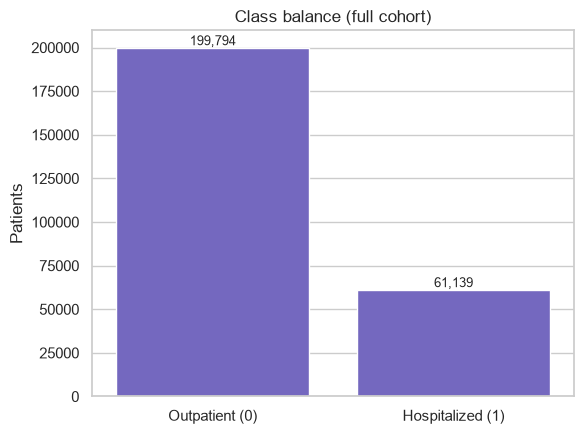

In [8]:
# EDA plot 3: class balance (full cohort)
fig, ax = plt.subplots(figsize=(6, 4.5))
cb = y.value_counts().sort_index()
sns.barplot(x=['Outpatient (0)', 'Hospitalized (1)'], y=cb.values, color='slateblue', ax=ax)
ax.set_title('Class balance (full cohort)')
ax.set_ylabel('Patients')
for i, v in enumerate(cb.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

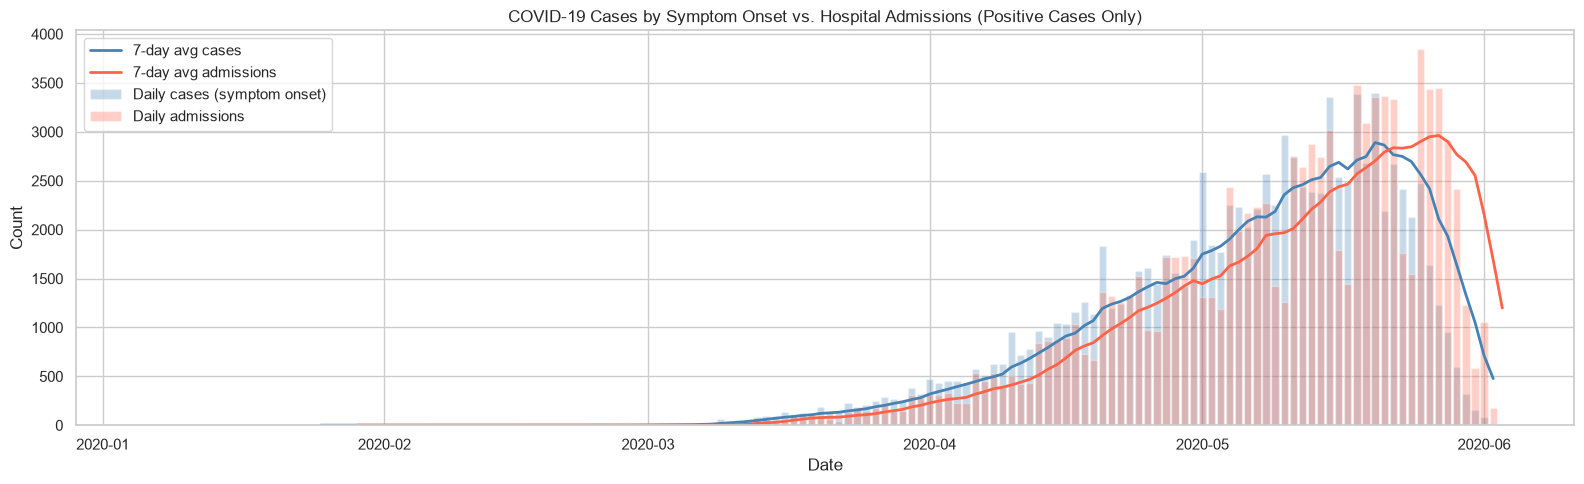

In [9]:
# EDA plot 4: dataset-level time series — daily positive cases vs. hospital admissions
positives = df[df['result'] == 'Positive']

daily_cases = (
    positives
    .groupby('symptoms_onset_date')
    .size()
    .rename('new_cases')
    .sort_index()
)
rolling_avg = daily_cases.rolling(window=7).mean()

daily_admissions = (
    positives
    .groupby('admission_date')
    .size()
    .rename('admissions')
    .sort_index()
)
rolling_avg_adm = daily_admissions.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(daily_cases.index, daily_cases, color='steelblue', alpha=0.3, label='Daily cases (symptom onset)')
ax.plot(rolling_avg.index, rolling_avg, color='steelblue', linewidth=2, label='7-day avg cases')

ax.bar(daily_admissions.index, daily_admissions, color='tomato', alpha=0.3, label='Daily admissions')
ax.plot(rolling_avg_adm.index, rolling_avg_adm, color='tomato', linewidth=2, label='7-day avg admissions')

ax.set_title('COVID-19 Cases by Symptom Onset vs. Hospital Admissions (Positive Cases Only)')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# EDA plot 5: KMeans clustering on [age, sex, #comorbidities] (target is NOT an input).
# Two interactive 3D scatters side by side, opened in the browser:
# left coloured by KMeans cluster, right coloured by hospitalization outcome.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

clust = pd.DataFrame({
    'age': data['age'],
    'sex': data['sex'].map({'Female': 0, 'Male': 1}),   # 'Not specified' -> NaN, dropped below
    'n_comorbidities': data[comorbidity_cols].sum(axis=1),
    'target': data['target'],
}).dropna(subset=['age', 'sex', 'n_comorbidities']).reset_index(drop=True)

# Cluster on age, sex and comorbidity count only — the outcome is a label, not a feature.
cluster_features = ['age', 'sex', 'n_comorbidities']
Z = StandardScaler().fit_transform(clust[cluster_features])
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
clust['cluster'] = kmeans.fit_predict(Z).astype(str)
clust['outcome'] = np.where(clust['target'] == 1, 'Hospitalized', 'Outpatient')

# Sample + jitter the discrete axes (sex is 0/1, comorbidity count is an integer) for readability
rng = np.random.RandomState(RANDOM_STATE)
sample = rng.choice(len(clust), size=min(5000, len(clust)), replace=False)
plot_df = clust.iloc[sample].copy()
plot_df['sex_jit'] = plot_df['sex'] + rng.uniform(-0.08, 0.08, len(plot_df))
plot_df['comorbidities_jit'] = plot_df['n_comorbidities'] + rng.uniform(-0.25, 0.25, len(plot_df))

# CVD-safe categorical colours (fixed assignment, not cycled)
CLUSTER_COLORS = {'0': '#2a78d6', '1': '#1baf7a', '2': '#eda100', '3': '#008300'}
OUTCOME_COLORS = {'Outpatient': '#2a78d6', 'Hospitalized': '#e34948'}

fig = make_subplots(
    rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('Coloured by KMeans cluster', 'Coloured by hospitalization outcome'),
)

for c, colour in CLUSTER_COLORS.items():
    sub = plot_df[plot_df['cluster'] == c]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=f'Cluster {c}',
        legendgroup='cluster', legendgrouptitle_text='Cluster',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=1)

for outcome, colour in OUTCOME_COLORS.items():
    sub = plot_df[plot_df['outcome'] == outcome]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=outcome,
        legendgroup='outcome', legendgrouptitle_text='Outcome',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=2)

fig.update_scenes(xaxis_title='Age', yaxis_title='# comorbidities',
                  zaxis_title='Sex (0 = Female, 1 = Male)')
fig.update_layout(
    title='Patient clusters on [age, sex, # comorbidities] vs. hospitalization outcome',
    height=750, width=1500,
)
fig.show()

# Cluster profiles: how the clusters differ, and their hospitalization rate
profile = clust.groupby('cluster').agg(
    n=('target', 'size'),
    mean_age=('age', 'mean'),
    share_male=('sex', 'mean'),
    mean_comorbidities=('n_comorbidities', 'mean'),
    hospitalization_rate=('target', 'mean'),
).round(2)
print("Cluster profiles (hospitalization_rate shows how each cluster relates to the outcome):")
print(profile)

Cluster profiles (hospitalization_rate shows how each cluster relates to the outcome):
              n  mean_age  share_male  mean_comorbidities  \
cluster                                                     
0        103572     37.62        0.00                0.32   
1         71807     30.96        1.00                0.30   
2         32324     59.10        0.27                2.64   
3         53230     57.69        0.99                0.88   

         hospitalization_rate  
cluster                        
0                        0.13  
1                        0.14  
2                        0.49  
3                        0.41  


### Fairness and potential harms

- **Representation.** Severity-based testing skews the cohort toward severe presentations; within it, older adults and men tend to show higher admission rates, while children and mild cases are under-represented, so the model has little reliable signal for them.
- **Access to care as a confounder.** `sector` records which health subsystem a patient reached (IMSS, ISSSTE, private, SSA, …). Admission probability partly reflects **bed availability and institutional practice**, not purely clinical need, so the model may encode socioeconomic access to care.
- **Under-served subgroups.** Indigenous-language speakers, migrants, and foreign nationals are small subgroups with heavy `Not specified` rates; predictions for them are likely both less accurate and less trustworthy.
- **Who is harmed by errors.** A **false negative** (predicting outpatient for someone who in fact needs admission) is the clinically dangerous error. Any deployment must prioritise recall for high-risk groups and must **never** be used to justify denying admission.

# Section B — Model Comparison

We compare three genuinely different families against a trivial reference, all sharing the same leakage-safe preprocessing and evaluated with 5-fold stratified CV on the **training set only**:

- **Dummy (prior)** — trivial baseline that always predicts the majority class / base rate.
- **Logistic Regression** — simple, interpretable linear model.
- **Random Forest** — bagged nonlinear trees.
- **Neural Network (MLP)** — multi-layer perceptron on the scaled / one-hot encoded features.

**Primary metric: ROC-AUC** (threshold-independent and robust to the class imbalance), reported alongside PR-AUC, F1 and recall so we can see behaviour at the default threshold.

**Pre-experiment expectation.** I expect the **MLP to win**: admission is driven mainly by age and comorbidity burden with likely nonlinearities and interactions (e.g. age × diabetes), which a neural network can capture once the inputs are scaled and one-hot encoded. I expect **logistic regression to be a close second** because much of the age/comorbidity effect is roughly monotone, **random forest in between**, and all three well above the dummy.

### Train/test split (created before any model selection)

We use a **stratified random 80/20 split** with a fixed seed. A random split is appropriate here because each row is already a distinct patient — the `registry_id` count equals the number of rows (checked above) — so there is no repeated-patient leakage across folds; and we are not claiming temporal extrapolation, which would instead call for an earlier-vs-later split. The test indices are saved to disk immediately and are not touched again during EDA, model comparison, or hyperparameter search — only in the final evaluation.

In [12]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    data.index.to_numpy(),
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Persist the split BEFORE any model selection (reproducibility checklist)
np.save('train_idx.npy', train_idx)
np.save('test_idx.npy', test_idx)

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
train_data = data.loc[train_idx]   # training-set frame used for EDA

print(f"Train: {len(train_idx):,}  |  Test: {len(test_idx):,}")
print(f"Train prevalence: {y_train.mean():.3f}  |  Test prevalence: {y_test.mean():.3f}")

Train: 208,746  |  Test: 52,187
Train prevalence: 0.234  |  Test prevalence: 0.234


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_preprocessor():
    """Preprocessing shared by every model. No imputation — missingness was handled during
    feature cleaning (rows dropped, set to No, or given an explicit 'Unknown' category)."""
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate

scoring = ['roc_auc', 'average_precision', 'f1', 'recall']

models = {
    'Dummy (prior)':        DummyClassifier(strategy='prior'),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                   random_state=RANDOM_STATE),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64,), early_stopping=True,
                                          max_iter=200, random_state=RANDOM_STATE),
}

rows = []
for name, clf in models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'model':   name,
        'ROC_AUC': res['test_roc_auc'].mean(),
        'PR_AUC':  res['test_average_precision'].mean(),
        'F1':      res['test_f1'].mean(),
        'Recall':  res['test_recall'].mean(),
    })

results = pd.DataFrame(rows).set_index('model').round(3)
results

,ROC_AUC,PR_AUC,F1,Recall
model,,,,
Dummy (prior),0.500,0.234,0.000,0.000
Logistic Regression,0.843,0.645,0.554,0.457
Random Forest,0.853,0.655,0.618,0.583
Neural Network (MLP),0.892,0.737,0.656,0.591


# Section C — Final Pipeline, Cross-Validation & Hyperparameter Search

We wrap **all learned steps** (scaling, one-hot encoding, and the classifier) into a single `Pipeline`, so every preprocessing transform is fit only on the training folds and never sees the test set. (No imputation step is needed — missing values were resolved during feature cleaning.) From Section B we take the **neural network (MLP)** as the final family and tune it with **Optuna** (TPE sampler, seeded for reproducibility) using the same 5-fold stratified CV on the training set, optimising ROC-AUC.

**Search space.** Depth (1–2 hidden layers), width per layer (32–256 units, log scale), L2 penalty `alpha` (1e-6–1e-1, log), initial learning rate (1e-4–1e-2, log), and batch size {128, 256, 512}. Each candidate uses early stopping on an internal 10% validation split, so `max_iter` acts as a cap rather than a tuned parameter.

**Search budget.** Optuna runs **30 trials**; each is scored with 5-fold CV, so **150 fitted models** plus one final refit — under the ~200 budget. Unlike a grid, the TPE sampler adapts: later trials concentrate around the regions that scored well earlier. Below we report the protocol, the trial/fit counts, the best hyperparameters, and the best validation score. The held-out test set is used only in the final evaluation cell.

In [15]:
import optuna
from sklearn.model_selection import cross_val_score

N_TRIALS = 30


def make_mlp(trial):
    """Build an MLPClassifier from an Optuna trial (also works with a FixedTrial for the refit)."""
    n_layers = trial.suggest_int('n_layers', 1, 2)
    hidden = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
                   for i in range(n_layers))
    return MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
        learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        batch_size=trial.suggest_categorical('batch_size', [128, 256, 512]),
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        max_iter=200, random_state=RANDOM_STATE,
    )


def objective(trial):
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_mlp(trial))])
    return cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring='roc_auc', n_jobs=-1).mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)   # keep the notebook output readable
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Trials: {len(study.trials)}  |  Total CV fits: {len(study.trials) * cv.get_n_splits()}")
print(f"\nBest CV ROC-AUC: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k} = {v}")

# Refit the best configuration on the full training set (what GridSearchCV's refit=True did)
best_model = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', make_mlp(optuna.trial.FixedTrial(study.best_params))),
]).fit(X_train, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

Trials: 30  |  Total CV fits: 150

Best CV ROC-AUC: 0.8928
Best hyperparameters:
  n_layers = 1
  n_units_l0 = 252
  alpha = 0.0008539011709630131
  learning_rate_init = 0.0001887720174152761
  batch_size = 256


=== Held-out test performance (evaluated once, after model selection) ===
ROC-AUC  : 0.891
PR-AUC   : 0.736
F1       : 0.651
Precision: 0.743
Recall   : 0.579


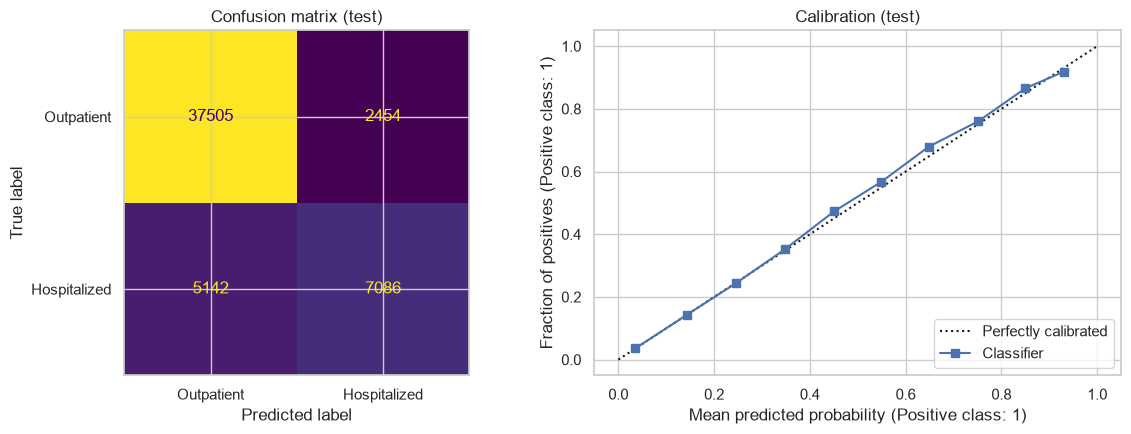

In [16]:
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             recall_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay

# `best_model` was refit on the full training set in the search cell above

test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = best_model.predict(X_test)

print("=== Held-out test performance (evaluated once, after model selection) ===")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_proba):.3f}")
print(f"F1       : {f1_score(y_test, test_pred):.3f}")
print(f"Precision: {precision_score(y_test, test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, test_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix (test)')
CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration (test)')
plt.tight_layout(); plt.show()

## [V2 ADDED] Final-model evaluation plots

Report-ready diagnostics for the tuned final model on the held-out test set: ROC and
precision–recall curves, a threshold sweep (precision / recall / F1 vs. decision threshold),
the predicted-probability distribution by true class, permutation feature importance, and
false-negative rate by age band. These complement the confusion matrix and calibration plot
above and drop straight into the report.

*Note:* the max-F1 threshold marked below is computed on the test set for illustration only;
for an honest operating point, choose the threshold on validation/CV data and apply it once to
the test set.

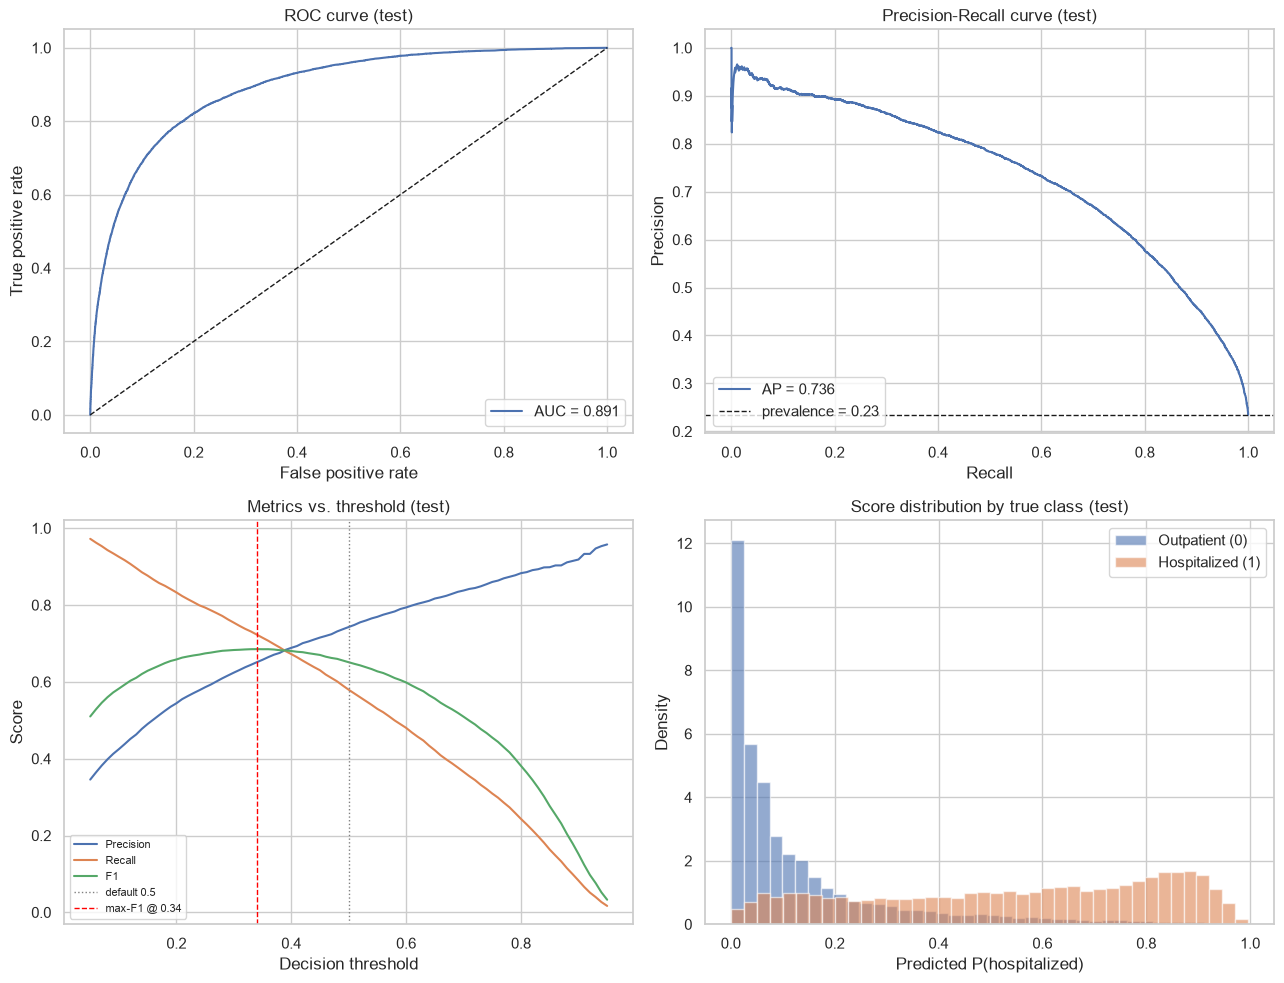

Max-F1 threshold on test = 0.34  (precision=0.651, recall=0.723)
NOTE: pick the operating threshold on validation/CV data, not on the test set, for the report.


In [17]:
# ===== [V2 ADDED] Four-panel evaluation figure for the final model (test set). =====
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, f1_score, precision_score, recall_score)

proba = best_model.predict_proba(X_test)[:, 1]   # reuse the tuned final pipeline

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_xlabel("False positive rate"); axes[0, 0].set_ylabel("True positive rate")
axes[0, 0].set_title("ROC curve (test)"); axes[0, 0].legend(loc="lower right")

# (2) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[0, 1].plot(rec, prec, label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[0, 1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[0, 1].set_xlabel("Recall"); axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall curve (test)"); axes[0, 1].legend(loc="lower left")

# (3) Threshold sweep: precision / recall / F1 vs decision threshold
thresholds = np.linspace(0.05, 0.95, 91)
prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    prec_t.append(precision_score(y_test, pred_t, zero_division=0))
    rec_t.append(recall_score(y_test, pred_t, zero_division=0))
    f1_t.append(f1_score(y_test, pred_t, zero_division=0))
best_t = float(thresholds[int(np.argmax(f1_t))])
axes[1, 0].plot(thresholds, prec_t, label="Precision")
axes[1, 0].plot(thresholds, rec_t, label="Recall")
axes[1, 0].plot(thresholds, f1_t, label="F1")
axes[1, 0].axvline(0.5, color='grey', ls=':', lw=1, label="default 0.5")
axes[1, 0].axvline(best_t, color='red', ls='--', lw=1, label=f"max-F1 @ {best_t:.2f}")
axes[1, 0].set_xlabel("Decision threshold"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Metrics vs. threshold (test)"); axes[1, 0].legend(fontsize=8)

# (4) Predicted-probability distribution by true class
axes[1, 1].hist(proba[y_test.to_numpy() == 0], bins=40, alpha=0.6, density=True, label="Outpatient (0)")
axes[1, 1].hist(proba[y_test.to_numpy() == 1], bins=40, alpha=0.6, density=True, label="Hospitalized (1)")
axes[1, 1].set_xlabel("Predicted P(hospitalized)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Score distribution by true class (test)"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

pred_bt = (proba >= best_t).astype(int)
print(f"Max-F1 threshold on test = {best_t:.2f}  "
      f"(precision={precision_score(y_test, pred_bt, zero_division=0):.3f}, "
      f"recall={recall_score(y_test, pred_bt, zero_division=0):.3f})")
print("NOTE: pick the operating threshold on validation/CV data, not on the test set, for the report.")


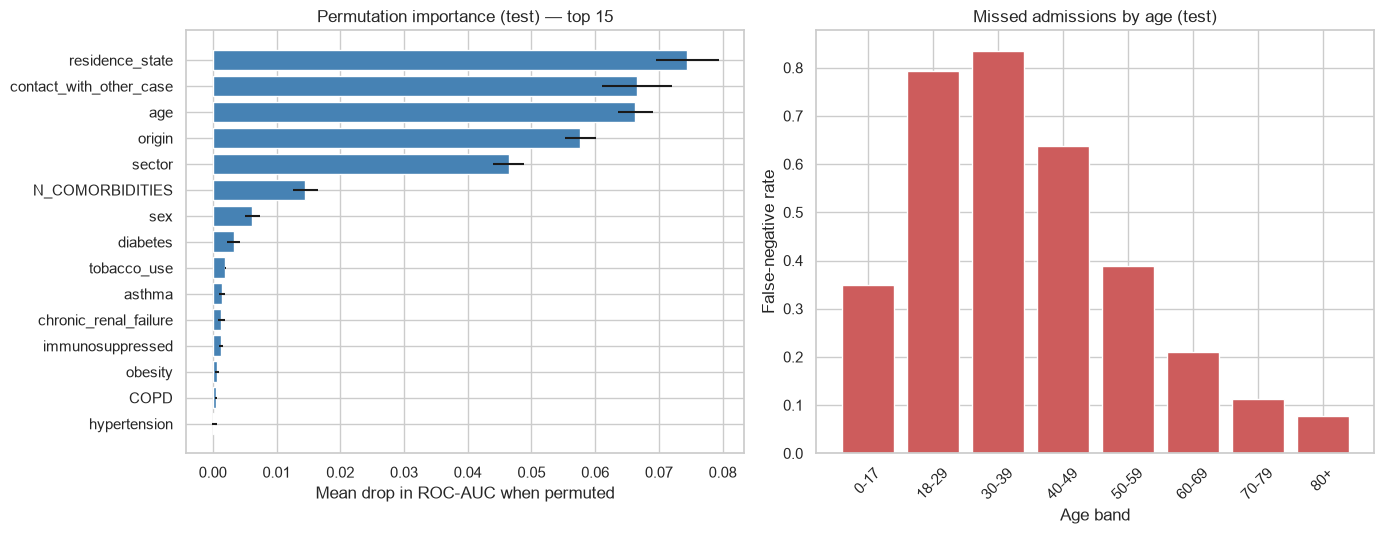

In [18]:
# ===== [V2 ADDED] Permutation importance + false-negative rate by age band (test). =====
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (left) Permutation feature importance: drop in ROC-AUC when each raw feature is shuffled.
# Subsampled for speed; raise n_pi / n_repeats for a more stable estimate.
rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(5000, len(X_test))
sub = rng.choice(len(X_test), size=n_pi, replace=False)
pi = permutation_importance(best_model, X_test.iloc[sub], y_test.iloc[sub],
                            scoring='roc_auc', n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(15)
axes[0].barh(imp.index, imp.values,
             xerr=pd.Series(pi.importances_std, index=X_test.columns).loc[imp.index],
             color='steelblue')
axes[0].set_xlabel("Mean drop in ROC-AUC when permuted")
axes[0].set_title("Permutation importance (test) — top 15")

# (right) False-negative rate by age band: share of truly-hospitalized patients sent home.
tmp = pd.DataFrame({'age': X_test['age'].to_numpy(),
                    'y_true': y_test.to_numpy(), 'y_pred': test_pred})
tmp['age_band'] = pd.cut(tmp['age'], bins=age_bins, labels=age_labels, right=False)
pos = tmp[tmp['y_true'] == 1]
fn_rate = pos.groupby('age_band', observed=True)['y_pred'].apply(lambda s: (s == 0).mean())
axes[1].bar(fn_rate.index.astype(str), fn_rate.values, color='indianred')
axes[1].set_xlabel("Age band"); axes[1].set_ylabel("False-negative rate")
axes[1].set_title("Missed admissions by age (test)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


### Error analysis

We examine where the final model errs on the **test set**, sliced by age band, sex, comorbidity burden, and health sector, to distinguish systematic bias from genuine unpredictability. We report per-group error rate and, because false negatives are the clinically dangerous case, the group false-negative rate (share of truly-hospitalized patients predicted as outpatient).

In [19]:
err = X_test.copy()
err['y_true'] = y_test.values
err['y_pred'] = test_pred
err['age_band'] = pd.cut(err['age'], bins=age_bins, labels=age_labels, right=False)
err['n_comorb'] = err[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4).astype(int)


def group_report(col):
    def summarize(sub):
        pos = sub['y_true'] == 1
        false_neg = (pos & (sub['y_pred'] == 0)).sum()
        return pd.Series({
            'n': len(sub),
            'error_rate': 1 - (sub['y_true'] == sub['y_pred']).mean(),
            'false_neg_rate': false_neg / max(int(pos.sum()), 1),
        })
    return err.groupby(col, observed=True).apply(summarize, include_groups=False).round(3)


for col in ['age_band', 'sex', 'n_comorb', 'sector']:
    print(f"\n=== Error by {col} ===")
    print(group_report(col))


=== Error by age_band ===
                n  error_rate  false_neg_rate
age_band                                     
0-17       2532.0       0.191           0.350
18-29      8890.0       0.076           0.792
30-39     12608.0       0.103           0.835
40-49     11587.0       0.152           0.638
50-59      8442.0       0.196           0.388
60-69      4586.0       0.216           0.210
70-79      2299.0       0.207           0.112
80+        1243.0       0.198           0.078

=== Error by sex ===
              n  error_rate  false_neg_rate
sex                                        
Female  25629.0       0.128           0.480
Male    26558.0       0.163           0.381

=== Error by n_comorb ===
                n  error_rate  false_neg_rate
n_comorb                                     
0         29295.0       0.115           0.593
1         13508.0       0.161           0.416
2          6069.0       0.210           0.285
3          2328.0       0.223           0.208
4           

**Error-analysis takeaways.** Two distinct patterns emerge. **Overall error rate** peaks in the clinically ambiguous middle — age 50–59 (~27%) and 4+ comorbidities (~31%) — where the admission decision is genuinely a judgment call and hardest to predict. The **dangerous error (false negatives)** shows the opposite gradient: it is concentrated in **young, low-comorbidity** patients (age 18–29: ~82% of true admissions missed; 0 comorbidities: ~48%) and is very low for the elderly (70–79: ~7%). The model has learned the base rate — a young, otherwise-healthy patient who nonetheless requires admission is rare and atypical, so the model defaults them to *outpatient*. This is a **base-rate / limited-signal effect, not a correctable bug**: presentation-time features simply do not separate the rare severe young cases. Differences across `sector` (e.g. higher false-negative rates in small private/military units) more likely reflect **institutional admission thresholds and bed capacity** — plus very small sample sizes for minor sectors — than genuine model bias, i.e. a data/deployment limitation. The practical implication is the one flagged in the fairness note: a deployed model should **lower the decision threshold for younger patients** or defer to clinicians there, and must never be used to deny admission.

In [20]:
import sklearn, matplotlib, seaborn, plotly, optuna

print("Library versions")
for m in [np, pd, sklearn, matplotlib, seaborn, plotly, optuna]:
    print(f"  {m.__name__}: {m.__version__}")

print(f"\nRANDOM_STATE = {RANDOM_STATE}")
print("Saved split indices: train_idx.npy, test_idx.npy")
print(f"Reload check: train={len(np.load('train_idx.npy')):,}, "
      f"test={len(np.load('test_idx.npy')):,}")

Library versions
  numpy: 2.5.1
  pandas: 3.0.3
  sklearn: 1.9.0
  matplotlib: 3.11.0
  seaborn: 0.13.2
  plotly: 6.8.0
  optuna: 4.9.0

RANDOM_STATE = 42
Saved split indices: train_idx.npy, test_idx.npy
Reload check: train=208,746, test=52,187
